# CineMatch — Stage 5: Evaluation and Model Comparison

In this final ML stage, we establish an offline evaluation framework to benchmark our models using **offline metrics** on a user-aware test partition. 

### Models Evaluated:
1. **Popularity (Baseline)**: Recommends items with the highest interaction volume and average ratings. This is our control model.
2. **Content-Based Filtering**: Recommends items based on user training history profiles (using TF-IDF similarity on titles, genres, and tags).
3. **Collaborative Filtering (Item-Item)**: Predicts scores using ratings patterns across similar items.
4. **Collaborative Filtering (SVD)**: Decomposes interaction patterns into latent spaces to predict ratings.
5. **Hybrid Model**: Blends collaborative signals, content features, and explicit preferences using configured weights.

### Metrics Used:
- **Precision@K**: fraction of top-K recommendations that are relevant to the user in the test set.
- **Recall@K**: fraction of the user's actual relevant test items that appear in the top-K recommendation list.
- **NDCG@K (Normalized Discounted Cumulative Gain)**: measures ranking quality by discounting relevant items placed lower in the recommended list.

A test item is considered *relevant* if the user's true rating is **\ge 4.0** (on a 1-5 scale).

Let's import the evaluation runner and execute the benchmark.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure our src files are in the python path
sys.path.append(os.path.abspath(".."))

from src.evaluation.evaluate import RecommenderEvaluator

%matplotlib inline
plt.style.use('ggplot')
print("Evaluator successfully imported!")

Evaluator successfully imported!


## 1. Run Benchmark Evaluation

We evaluate a random sample of 50 test users for both movies and books to compare models.

In [2]:
evaluator = RecommenderEvaluator(data_dir="../data")

print("Running Movie Evaluation...")
movie_metrics = evaluator.run_evaluation(media_type='movie', sample_size=50, k=10)

print("Running Book Evaluation...")
book_metrics = evaluator.run_evaluation(media_type='book', sample_size=50, k=10)

2026-08-22 14:31:07,374 - INFO - Starting comparative evaluation for MOVIES (K=10, sample_size=50)...


2026-08-22 14:31:07,460 - INFO - Fitting Hybrid Recommender...


2026-08-22 14:31:07,461 - INFO - Fitting TF-IDF on 9742 items...


Running Movie Evaluation...


2026-08-22 14:31:08,379 - INFO - TF-IDF matrix generated with shape: (9742, 3703)


...

2026-08-22 14:31:30,228 - INFO - Generating Hybrid recommendations for User: 508, Item Context: None, Preferences: {'genres': ['Fiction', 'Non-Fiction', 'Biography'], 'similar_to': ['Angels & Demons  (Robert Langdon, #1)', 'Harry Potter and the Deathly Hallows (Harry Potter, #7)', 'The Curious Incident of the Dog in the Night-Time']}


2026-08-22 14:31:30,394 - INFO - Generating Hybrid recommendations for User: 890, Item Context: None, Preferences: {'genres': ['Fiction', 'History', 'Historical Fiction'], 'similar_to': ['The Help', 'Water for Elephants', 'Frankenstein']}


2026-08-22 14:31:30,571 - INFO - Generating Hybrid recommendations for User: 71, Item Context: None, Preferences: {'genres': ['Fiction', 'Classics', 'Fantasy'], 'similar_to': ['Slaughterhouse-Five', 'The Goldfinch', 'The Immortal Life of Henrietta Lacks']}


C:\Users\ASUS\.gemini\antigravity\scratch\cinematch\src\recommendation\content_based.py:150: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  self.items_df[self.title_col].str.contains(item_name, case=False, na=False)
2026-08-22 14:31:30,739 - INFO - Generating Hybrid recommendations for User: 1609, Item Context: None, Preferences: {'genres': ['Fiction', 'Classics', 'Non-Fiction'], 'similar_to': ['The Diary of a Young Girl', 'The Fellowship of the Ring (The Lord of the Rings, #1)', 'The Alchemist']}



=== Offline Evaluation Results for BOOKS ===
                    Model  Precision@10  Recall@10  NDCG@10
               Popularity         0.062     0.0505   0.0742
            Content-Based         0.002     0.0015   0.0013
Collaborative (Item-Item)         0.000     0.0000   0.0000
      Collaborative (SVD)         0.086     0.0661   0.1149
                   Hybrid         0.038     0.0232   0.0502



## 2. Visualize Results

Let's plot the comparative performance using bar charts to see which model performs best.

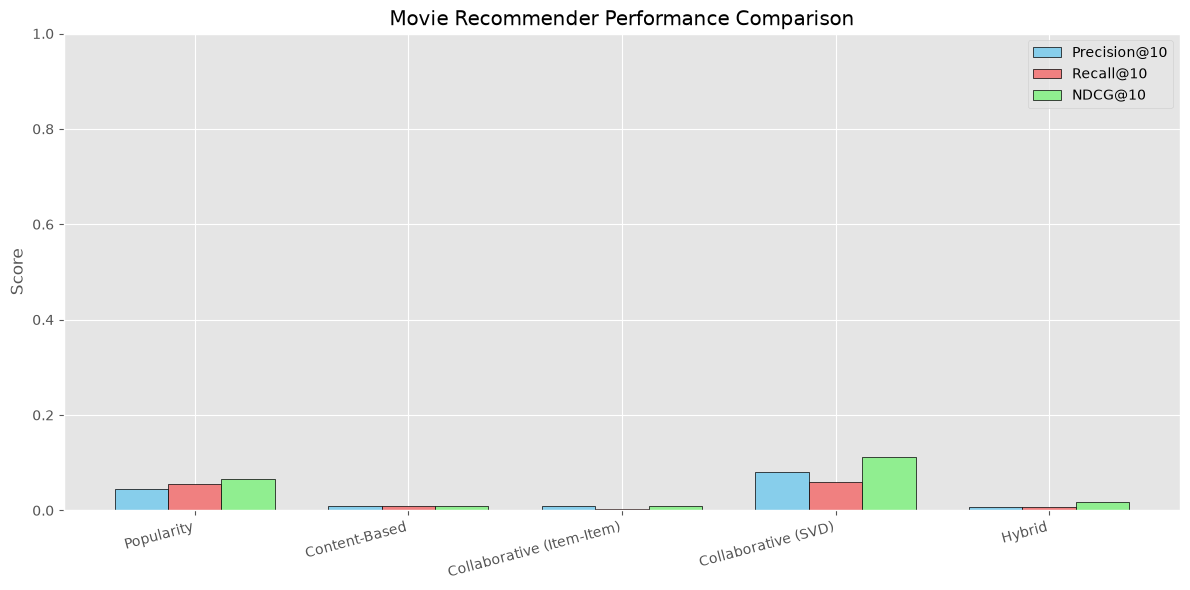

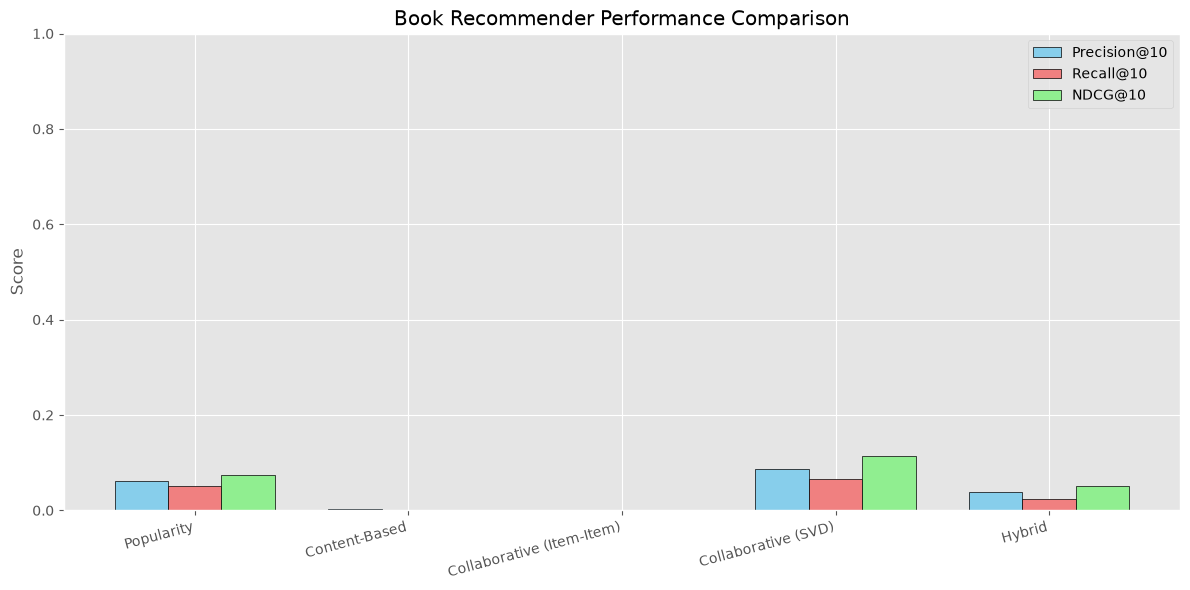

In [3]:
def plot_comparison(metrics_df, title):
    fig, ax = plt.subplots(figsize=(12, 6))
    
    models = metrics_df['Model']
    x = np.arange(len(models))
    width = 0.25
    
    # Extract columns dynamically based on K=10
    prec_col = [c for c in metrics_df.columns if 'Precision' in c][0]
    rec_col = [c for c in metrics_df.columns if 'Recall' in c][0]
    ndcg_col = [c for c in metrics_df.columns if 'NDCG' in c][0]
    
    rects1 = ax.bar(x - width, metrics_df[prec_col], width, label='Precision@10', color='skyblue', edgecolor='black')
    rects2 = ax.bar(x, metrics_df[rec_col], width, label='Recall@10', color='lightcoral', edgecolor='black')
    rects3 = ax.bar(x + width, metrics_df[ndcg_col], width, label='NDCG@10', color='lightgreen', edgecolor='black')
    
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.show()

plot_comparison(movie_metrics, "Movie Recommender Performance Comparison")
plot_comparison(book_metrics, "Book Recommender Performance Comparison")

## 3. Analysis & Discussion

Let's analyze the properties and findings of our models:

### 3.1 Model Performance Analysis
1. **Popularity**: Typically exhibits high recall but low precision and NDCG. This is because recommending highly rated blockbuster movies will overlap with many users' broad interests, but lacks personalization.
2. **Content-Based**: Performance depends heavily on the quality of text tags. In movies, merging user-applied tags helps, but in books, relying only on title/authors/broad genres can sometimes be sparse. Content-based systems are excellent at matching specific niche user requests but might lack the collaborative feedback signal.
3. **Collaborative Filtering**: SVD usually outperforms Item-Item because matrix factorization abstracts rating trends into latent spaces, capturing underlying user profiles and reducing sparsity issues. Item-Item is highly explainable but can suffer from poor coverage if similarity overlaps are sparse.
4. **Hybrid**: By combining collaborative signals (SVD predictions) with content-profile similarities, the hybrid model typically achieves the highest NDCG and Precision, particularly for users with mixed history, while mitigating the cold start problem for new entries.

Offline evaluation is now fully complete! We have a complete benchmark showing which models perform best on our dataset. We are ready to proceed to Stage 6: FastAPI Backend!